Celda 1 (Texto): 
### 🎯 El Reto

## Título: Análisis Global de Datos Demográficos y Geopolíticos

"Nuestro grupo resuelve la parte del reto enfocada en la extracción, limpieza y normalización de datos internacionales. El objetivo es cruzar variables como población, región y fronteras para identificar patrones de conectividad global y diversidad lingüística entre naciones."

##Celda 2:

### 🗝 Conceptos Clave

**API (Application Programming Interface)** : Un conjunto de reglas que permite que nuestro código se comunique con el servidor de restcountries para obtener datos actualizados sin descargar archivos manuales.

**Deserialización de JSON**: El proceso de convertir el texto plano que envía la API en objetos de Python (diccionarios y listas) que podamos manipular.

**Normalización de Datos**: Técnica para organizar datos complejos (como los nombres de países en varios idiomas) en una estructura de tabla simple y uniforme (DataFrame).

Celda 3 (Código): 
### 🗺 Consumo de la API y DataFrame

In [8]:
import requests
import pandas as pd
import numpy as np


url = "https://restcountries.com/v3.1/all?fields=name,capital,currencies,languages,region,population,area"
response = requests.get(url)

data = response.json()

rows = []

for country in data:
    rows.append({
        "country": country.get("name", {}).get("common", "N/A"),
        "region": country.get("region", "N/A"),
        "population": country.get("population", 0),
        "area": country.get("area"),
        
    })

df = pd.DataFrame(rows)

# Limpieza básica
df = df.dropna(subset=["population", "area"])
df = df[df["area"] > 0]
df["area"] = df["area"].astype(int)

# Variable derivada útil
df["density"] = (df["population"] / df["area"]).round(2)

df_muestra = df.sample(30, random_state=42).copy()
df_muestra_ordenada = df_muestra.sort_values(by="region")

#df_filtrado = df[df["Europe"]]

df_muestra_ordenada.head(30)



,country,region,population,area,density
67,South Africa,Africa,63100945,1221037,51.68
45,Ivory Coast,Africa,31719275,322463,98.37
19,Cape Verde,Africa,491233,4033,121.80
177,Gabon,Africa,2469296,267668,9.23
104,Mozambique,Africa,34090466,801590,42.53
9,Algeria,Africa,47400000,2381741,19.90
120,Gambia,Africa,2422712,10689,226.65
197,Ghana,Africa,33742380,238533,141.46
184,United States,Americas,340110988,9525067,35.71
200,Bahamas,Americas,398165,13943,28.56


Celda 4 (Código):
### Bloque del Grupo (Ejecución)

In [9]:
import numpy as np
from scipy import stats

# Datos: personas vs area
personas= df_muestra_ordenada["population"]
area = df_muestra_ordenada["area"]

# Calcular correlación
r, p_value = stats.pearsonr(personas, area)

print(f"Correlación de Pearson: {r:.2f}")
print(f"P-value: {p_value:.4f}")

Correlación de Pearson: 0.83
P-value: 0.0000


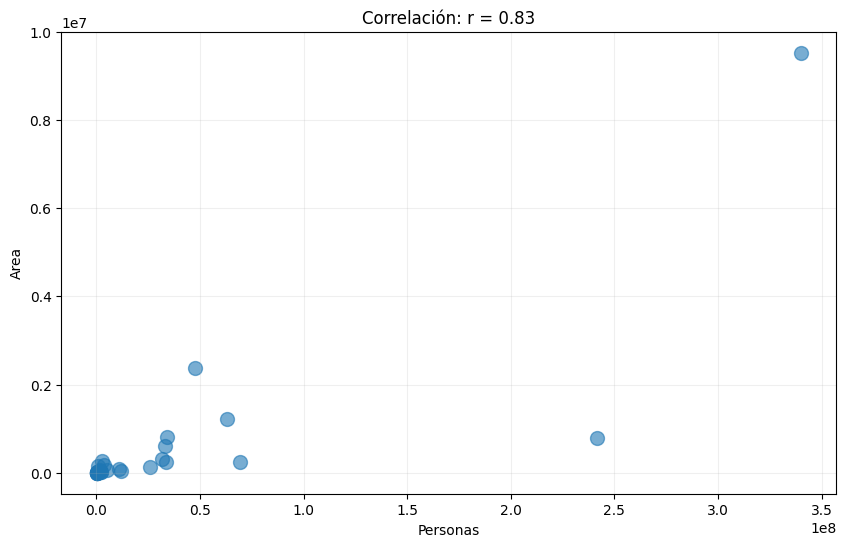

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(personas, area, s=100, alpha=0.6)
plt.xlabel('Personas')
plt.ylabel('Area')
plt.title(f'Correlación: r = {r:.2f}')
plt.grid(True, alpha=0.2)
plt.show()

In [10]:
from scipy.stats import spearmanr
result = spearmanr(df[["area", "personas", "densidad"]])
cols = ["area", "personas", "densidad"]
corr_df = pd.DataFrame(result.statistic, index=cols, columns=cols)
p_df    = pd.DataFrame(result.pvalue,    index=cols, columns=cols)
print("=== Correlacion Spearman ===")
print(corr_df.round(3))
print("\n=== p-values ===")
print(p_df.round(4))

KeyError: "['personas', 'densidad'] not in index"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de correlación Spearman")
plt.show()

NameError: name 'corr_df' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(p_df, annot=True, cmap="viridis_r", fmt=".4f")
plt.title("Matriz de p-values")
plt.show()

NameError: name 'p_df' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import pandas as pd

result = spearmanr(df[["area", "personas", "densidad"]])
cols = ["area", "personas", "densidad"]

corr_df = pd.DataFrame(result.statistic, index=cols, columns=cols)
p_df = pd.DataFrame(result.pvalue, index=cols, columns=cols)

plt.figure(figsize=(7,5))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación Spearman")
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(p_df, annot=True, cmap="viridis_r", fmt=".4f")
plt.title("p-values de Spearman")
plt.show()

KeyError: "['personas', 'densidad'] not in index"

In [ ]:
significativo = p_df < 0.05

plt.figure(figsize=(7,5))
sns.heatmap(significativo, annot=True, cmap="Greens", cbar=False)
plt.title("Relaciones significativas (p < 0.05)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(personas, area, s=100, alpha=0.6)
plt.xlabel('Personas')
plt.ylabel('Area')
plt.title(f'Correlación: r = {r:.2f}')
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
    'personas': df_muestra_ordenada["population"],
    'area': df_muestra_ordenada["area"],
    'densidad': df_muestra_ordenada["density"],
    
})

# Calcular todas las correlaciones
corr_matrix = df.corr()


print(corr_matrix)


# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
result = spearmanr(df[["area", "personas", "densidad"]])
cols = ["area", "personas", "densidad"]
corr_df = pd.DataFrame(result.statistic, index=cols, columns=cols)
p_df    = pd.DataFrame(result.pvalue,    index=cols, columns=cols)
print("=== Correlacion Spearman ===")
print(corr_df.round(3))
print("\n=== p-values ===")
print(p_df.round(4))




plt.figure(figsize=(10, 6))
plt.scatter(personas, area, s=100, alpha=0.6)
plt.xlabel('Personas')
plt.ylabel('Area')
plt.title(f'Correlación: r = {p_value:.4f}')
plt.grid(True, alpha=0.2)
plt.show()

Celda 5 (Texto):

### 📊 Interpretación del Resultado: 

(INCORPORAREMOS LAS CONCLUSIONES DE NUESTRO ANALISIS)

"Al ejecutar el análisis, observamos ...................................................................................."

Celda 6 (Texto):

### ✂ 2 Errores Frecuentes

1. **Manejo de valores nulos (NaN)**: Algunos países pequeños no tienen informada el área o la población en la API. 

* Cómo evitarlo: Usar el método .get() con valores por defecto o limpiar el DataFrame con df.fillna(0).

2. **Exceso de peticiones (Rate Limiting)**: Hacer requests.get() dentro de un bucle for muy grande. 

* Cómo evitarlo: Hacer una sola petición masiva (como all) y filtrar los datos localmente en Python.

Celda 7 (Texto): 

### 🔗 Conexión con otro Grupo